In [1]:
2+2

4

Total log entries: 16


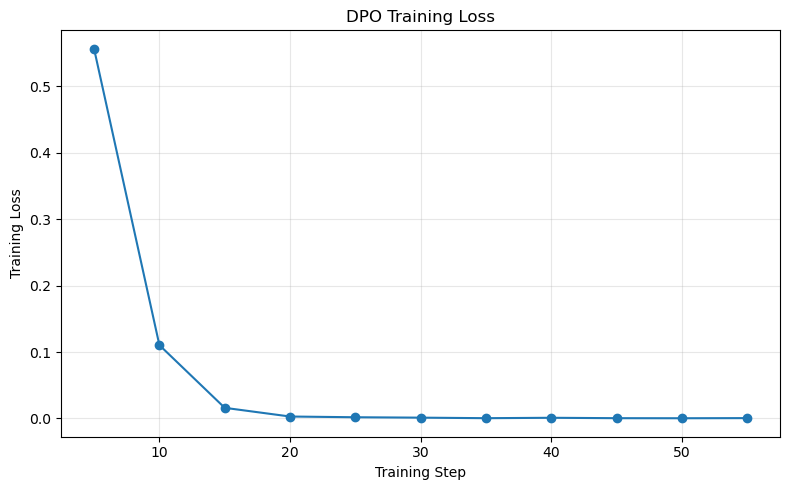

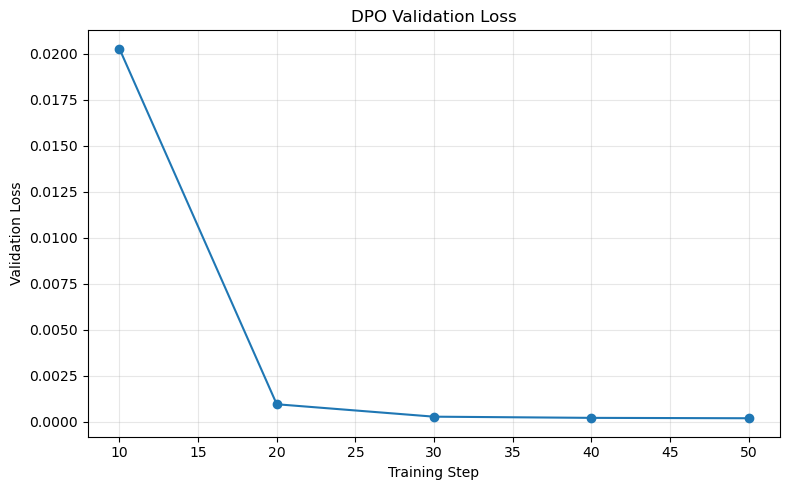

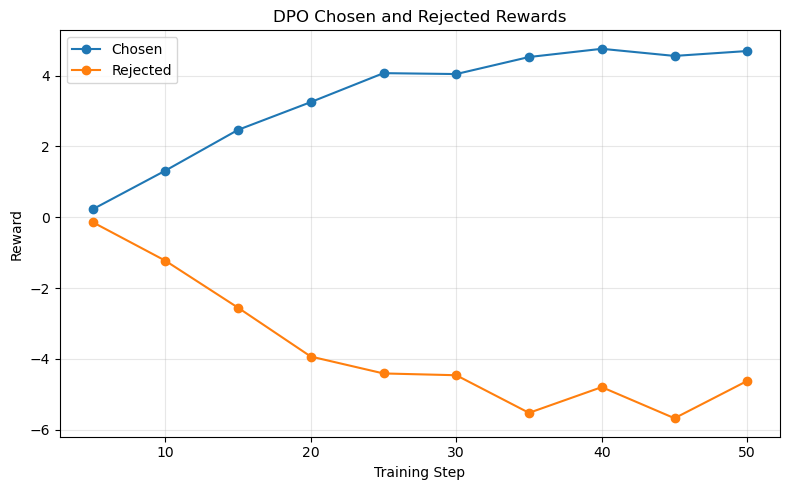

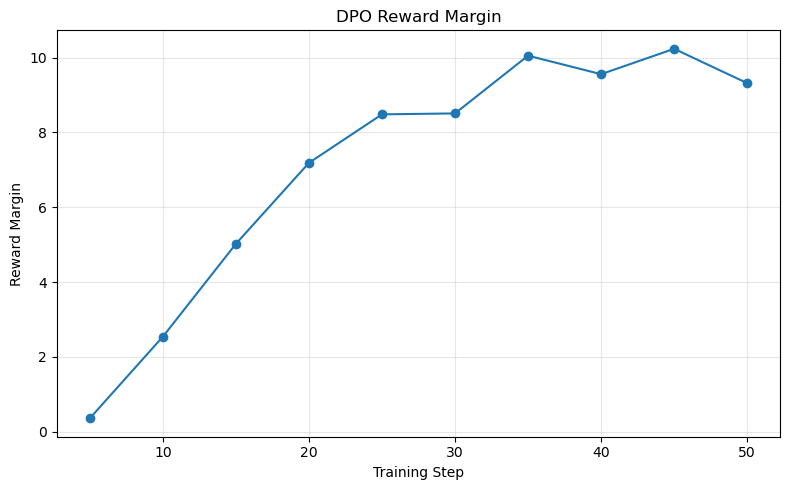

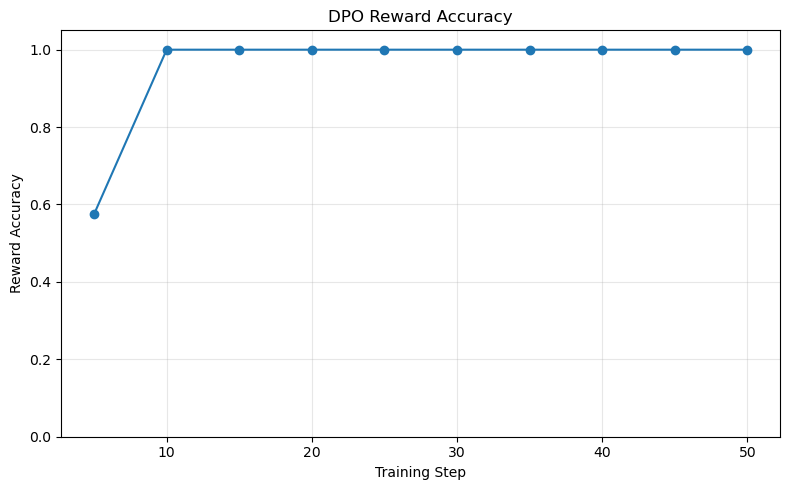

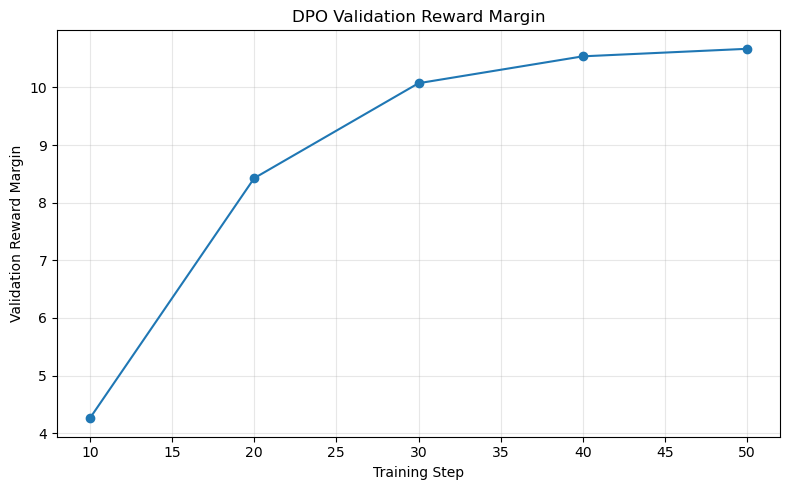


FINAL DPO METRICS
Final training loss      : 0.000500
Final validation loss    : 0.000181
Final chosen reward      : 4.695122
Final rejected reward    : -4.623719
Final reward margin      : 9.318842
Final reward accuracy    : 1.000000
Final validation margin  : 10.669306

✓ All plots saved successfully.


In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# 1. PATH TO TRAINER STATE
# ============================================================

TRAINER_STATE = Path(
    r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\DPO\qwen25_1.5b_dpo_final\checkpoint-57\trainer_state.json"
)

# If checkpoint-57 does not exist, change the path to the
# checkpoint folder that contains trainer_state.json.

# ============================================================
# 2. LOAD TRAINING HISTORY
# ============================================================

with open(TRAINER_STATE, "r", encoding="utf-8") as f:
    state = json.load(f)

history = state["log_history"]

print(f"Total log entries: {len(history)}")

# ============================================================
# 3. EXTRACT METRICS
# ============================================================

train_loss = []
train_steps = []

chosen_reward = []
rejected_reward = []
reward_margin = []
reward_accuracy = []
reward_steps = []

val_loss = []
val_steps = []

val_chosen_reward = []
val_rejected_reward = []
val_reward_margin = []
val_reward_accuracy = []
val_reward_steps = []

for log in history:

    step = log.get("step")

    # --------------------------------------------------------
    # TRAINING METRICS
    # --------------------------------------------------------

    if "loss" in log:
        train_steps.append(step)
        train_loss.append(log["loss"])

    if "rewards/chosen" in log:

        # Ignore NaN values
        if log["rewards/chosen"] is not None:

            chosen_reward.append(log["rewards/chosen"])
            rejected_reward.append(log.get("rewards/rejected"))
            reward_margin.append(log.get("rewards/margins"))
            reward_accuracy.append(log.get("rewards/accuracies"))
            reward_steps.append(step)

    # --------------------------------------------------------
    # VALIDATION METRICS
    # --------------------------------------------------------

    if "eval_loss" in log:

        val_steps.append(step)
        val_loss.append(log["eval_loss"])

        val_chosen_reward.append(
            log.get("eval_rewards/chosen")
        )

        val_rejected_reward.append(
            log.get("eval_rewards/rejected")
        )

        val_reward_margin.append(
            log.get("eval_rewards/margins")
        )

        val_reward_accuracy.append(
            log.get("eval_rewards/accuracies")
        )

        val_reward_steps.append(step)


# ============================================================
# 4. REMOVE NaN VALUES FROM TRAINING REWARD DATA
# ============================================================

clean_reward_data = [
    (
        s,
        c,
        r,
        m,
        a
    )
    for s, c, r, m, a in zip(
        reward_steps,
        chosen_reward,
        rejected_reward,
        reward_margin,
        reward_accuracy
    )
    if all(
        isinstance(x, (int, float)) and x == x
        for x in [c, r, m, a]
    )
]

if clean_reward_data:

    (
        reward_steps,
        chosen_reward,
        rejected_reward,
        reward_margin,
        reward_accuracy
    ) = zip(*clean_reward_data)

    reward_steps = list(reward_steps)
    chosen_reward = list(chosen_reward)
    rejected_reward = list(rejected_reward)
    reward_margin = list(reward_margin)
    reward_accuracy = list(reward_accuracy)


# ============================================================
# 5. PLOT 1 — TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    train_steps,
    train_loss,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("DPO Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. PLOT 2 — VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    val_steps,
    val_loss,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Validation Loss")
plt.title("DPO Validation Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. PLOT 3 — CHOSEN VS REJECTED REWARD
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    reward_steps,
    chosen_reward,
    marker="o",
    label="Chosen"
)

plt.plot(
    reward_steps,
    rejected_reward,
    marker="o",
    label="Rejected"
)

plt.xlabel("Training Step")
plt.ylabel("Reward")
plt.title("DPO Chosen and Rejected Rewards")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_chosen_vs_rejected_reward.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. PLOT 4 — REWARD MARGIN
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    reward_steps,
    reward_margin,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Reward Margin")
plt.title("DPO Reward Margin")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_reward_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. PLOT 5 — REWARD ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    reward_steps,
    reward_accuracy,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Reward Accuracy")
plt.title("DPO Reward Accuracy")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_reward_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. PLOT 6 — VALIDATION REWARD MARGIN
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    val_reward_steps,
    val_reward_margin,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Validation Reward Margin")
plt.title("DPO Validation Reward Margin")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_validation_reward_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. PRINT FINAL METRICS
# ============================================================

print("\n" + "=" * 60)
print("FINAL DPO METRICS")
print("=" * 60)

if train_loss:
    print(f"Final training loss      : {train_loss[-1]:.6f}")

if val_loss:
    print(f"Final validation loss    : {val_loss[-1]:.6f}")

if chosen_reward:
    print(f"Final chosen reward      : {chosen_reward[-1]:.6f}")

if rejected_reward:
    print(f"Final rejected reward    : {rejected_reward[-1]:.6f}")

if reward_margin:
    print(f"Final reward margin      : {reward_margin[-1]:.6f}")

if reward_accuracy:
    print(f"Final reward accuracy    : {reward_accuracy[-1]:.6f}")

if val_reward_margin:
    print(f"Final validation margin  : {val_reward_margin[-1]:.6f}")

print("=" * 60)

print("\n✓ All plots saved successfully.")

Total log entries: 16


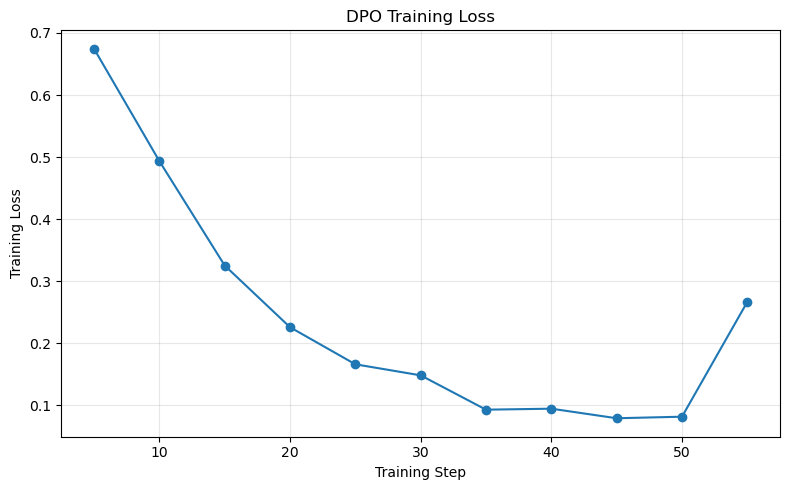

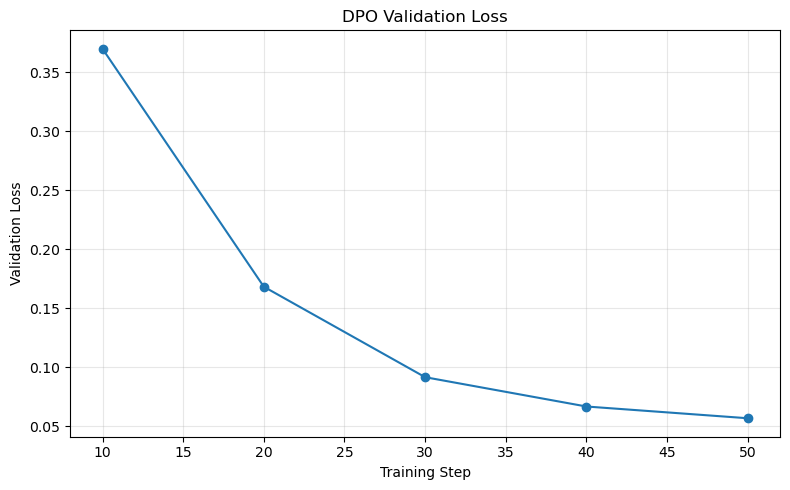

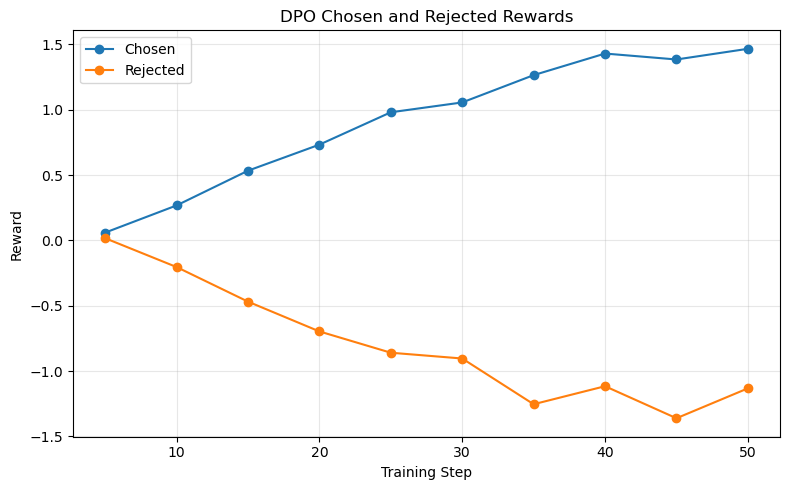

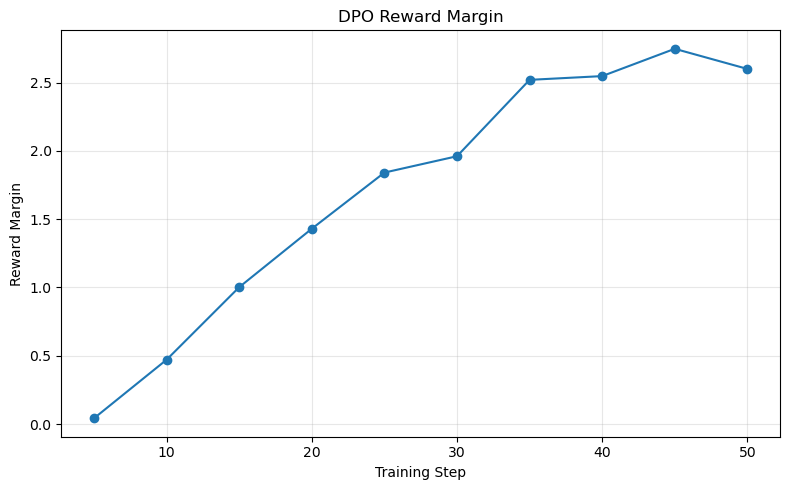

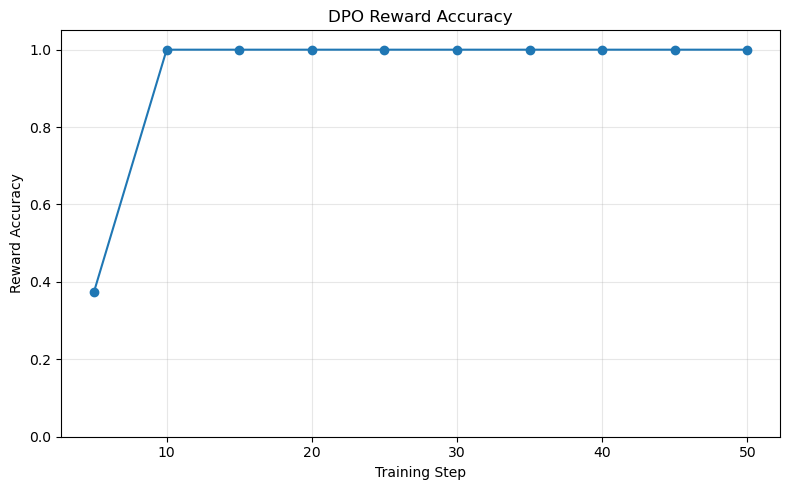

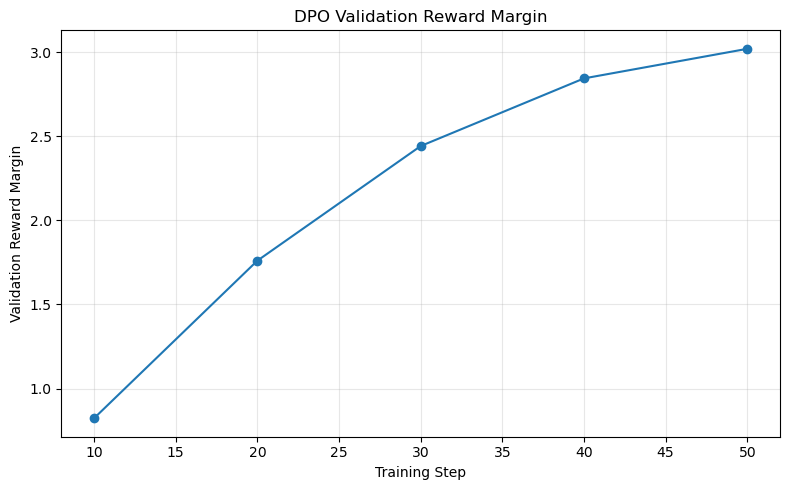


FINAL DPO METRICS
Final training loss      : 0.266900
Final validation loss    : 0.056794
Final chosen reward      : 1.466879
Final rejected reward    : -1.132664
Final reward margin      : 2.599543
Final reward accuracy    : 1.000000
Final validation margin  : 3.020382

✓ All plots saved successfully.


In [3]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# 1. PATH TO TRAINER STATE
# ============================================================

TRAINER_STATE = Path(
    r"C:\Users\Aman Kumar Singh\Desktop\nlp_dissertation\DPO\qwen25_1.5b_dpo_final_2\checkpoint-57\trainer_state.json"
)

# If checkpoint-57 does not exist, change the path to the
# checkpoint folder that contains trainer_state.json.

# ============================================================
# 2. LOAD TRAINING HISTORY
# ============================================================

with open(TRAINER_STATE, "r", encoding="utf-8") as f:
    state = json.load(f)

history = state["log_history"]

print(f"Total log entries: {len(history)}")

# ============================================================
# 3. EXTRACT METRICS
# ============================================================

train_loss = []
train_steps = []

chosen_reward = []
rejected_reward = []
reward_margin = []
reward_accuracy = []
reward_steps = []

val_loss = []
val_steps = []

val_chosen_reward = []
val_rejected_reward = []
val_reward_margin = []
val_reward_accuracy = []
val_reward_steps = []

for log in history:

    step = log.get("step")

    # --------------------------------------------------------
    # TRAINING METRICS
    # --------------------------------------------------------

    if "loss" in log:
        train_steps.append(step)
        train_loss.append(log["loss"])

    if "rewards/chosen" in log:

        # Ignore NaN values
        if log["rewards/chosen"] is not None:

            chosen_reward.append(log["rewards/chosen"])
            rejected_reward.append(log.get("rewards/rejected"))
            reward_margin.append(log.get("rewards/margins"))
            reward_accuracy.append(log.get("rewards/accuracies"))
            reward_steps.append(step)

    # --------------------------------------------------------
    # VALIDATION METRICS
    # --------------------------------------------------------

    if "eval_loss" in log:

        val_steps.append(step)
        val_loss.append(log["eval_loss"])

        val_chosen_reward.append(
            log.get("eval_rewards/chosen")
        )

        val_rejected_reward.append(
            log.get("eval_rewards/rejected")
        )

        val_reward_margin.append(
            log.get("eval_rewards/margins")
        )

        val_reward_accuracy.append(
            log.get("eval_rewards/accuracies")
        )

        val_reward_steps.append(step)


# ============================================================
# 4. REMOVE NaN VALUES FROM TRAINING REWARD DATA
# ============================================================

clean_reward_data = [
    (
        s,
        c,
        r,
        m,
        a
    )
    for s, c, r, m, a in zip(
        reward_steps,
        chosen_reward,
        rejected_reward,
        reward_margin,
        reward_accuracy
    )
    if all(
        isinstance(x, (int, float)) and x == x
        for x in [c, r, m, a]
    )
]

if clean_reward_data:

    (
        reward_steps,
        chosen_reward,
        rejected_reward,
        reward_margin,
        reward_accuracy
    ) = zip(*clean_reward_data)

    reward_steps = list(reward_steps)
    chosen_reward = list(chosen_reward)
    rejected_reward = list(rejected_reward)
    reward_margin = list(reward_margin)
    reward_accuracy = list(reward_accuracy)


# ============================================================
# 5. PLOT 1 — TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    train_steps,
    train_loss,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("DPO Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. PLOT 2 — VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    val_steps,
    val_loss,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Validation Loss")
plt.title("DPO Validation Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. PLOT 3 — CHOSEN VS REJECTED REWARD
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    reward_steps,
    chosen_reward,
    marker="o",
    label="Chosen"
)

plt.plot(
    reward_steps,
    rejected_reward,
    marker="o",
    label="Rejected"
)

plt.xlabel("Training Step")
plt.ylabel("Reward")
plt.title("DPO Chosen and Rejected Rewards")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_chosen_vs_rejected_reward.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. PLOT 4 — REWARD MARGIN
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    reward_steps,
    reward_margin,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Reward Margin")
plt.title("DPO Reward Margin")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_reward_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. PLOT 5 — REWARD ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    reward_steps,
    reward_accuracy,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Reward Accuracy")
plt.title("DPO Reward Accuracy")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_reward_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. PLOT 6 — VALIDATION REWARD MARGIN
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    val_reward_steps,
    val_reward_margin,
    marker="o"
)

plt.xlabel("Training Step")
plt.ylabel("Validation Reward Margin")
plt.title("DPO Validation Reward Margin")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "dpo_validation_reward_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. PRINT FINAL METRICS
# ============================================================

print("\n" + "=" * 60)
print("FINAL DPO METRICS")
print("=" * 60)

if train_loss:
    print(f"Final training loss      : {train_loss[-1]:.6f}")

if val_loss:
    print(f"Final validation loss    : {val_loss[-1]:.6f}")

if chosen_reward:
    print(f"Final chosen reward      : {chosen_reward[-1]:.6f}")

if rejected_reward:
    print(f"Final rejected reward    : {rejected_reward[-1]:.6f}")

if reward_margin:
    print(f"Final reward margin      : {reward_margin[-1]:.6f}")

if reward_accuracy:
    print(f"Final reward accuracy    : {reward_accuracy[-1]:.6f}")

if val_reward_margin:
    print(f"Final validation margin  : {val_reward_margin[-1]:.6f}")

print("=" * 60)

print("\n✓ All plots saved successfully.")